Dataset

In [1]:
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


STEP 1: Loading Dataset...
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)

STEP 2: Preprocessing...

STEP 3: Building CNN Model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


STEP 4: Compiling Model...

STEP 5: Training Model...
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - accuracy: 0.9205 - loss: 0.2613 - val_accuracy: 0.9810 - val_loss: 0.0649
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.9729 - loss: 0.0906 - val_accuracy: 0.9864 - val_loss: 0.0471
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.9803 - loss: 0.0663 - val_accuracy: 0.9872 - val_loss: 0.0481
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9840 - loss: 0.0530 - val_accuracy: 0.9868 - val_loss: 0.0467
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.9863 - loss: 0.0442 - val_accuracy: 0.9903 - val_loss: 0.0368
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step - accuracy: 0.9882 - loss: 0.0388 - val_accuracy: 0.9890 - val_loss: 0.0393
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9896 - loss: 0.0331 - val_accuracy: 0.9908 - val_loss: 0.0329
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━

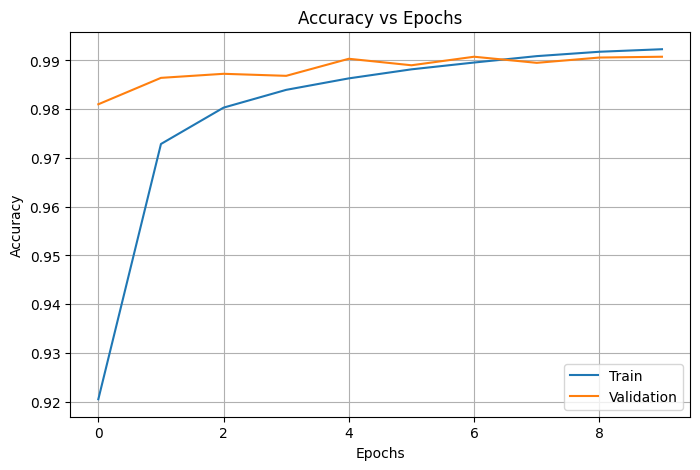

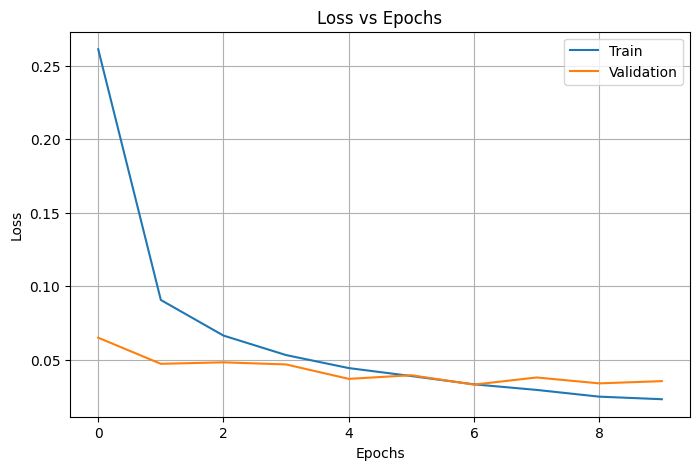

In [2]:
# ============================================================
# EXPERIMENT 8: CNN on MNIST Dataset
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# -------------------------------
# STEP 1: Load Dataset
# -------------------------------
print("STEP 1: Loading Dataset...")

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# -------------------------------
# STEP 2: Preprocessing
# -------------------------------
print("\nSTEP 2: Preprocessing...")

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# -------------------------------
# STEP 3: Build Model
# -------------------------------
print("\nSTEP 3: Building CNN Model...")

model = Sequential([
    tf.keras.Input(shape=(28,28,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.summary()

# -------------------------------
# STEP 4: Compile Model
# -------------------------------
print("\nSTEP 4: Compiling Model...")

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# STEP 5: Train Model
# -------------------------------
print("\nSTEP 5: Training Model...")

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# -------------------------------
# STEP 6: Evaluate Model
# -------------------------------
print("\nSTEP 6: Evaluating Model...")

loss, acc = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {acc*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

# -------------------------------
# STEP 7: Accuracy Graph
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.grid(True)
plt.show()

# -------------------------------
# STEP 8: Loss Graph
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.grid(True)
plt.show()